In [ ]:
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F


In [ ]:

optimizer = torch.optim.Adam(transformer.parameters(), 
                            lr=lr, 
                            weight_decay=cfg.wt_decay,
                            betas=(0.9, 0.98), 
                            eps=1e-9, )    
# main_lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, 
#                                                                T_max=num_epochs-3, 
#                                                                eta_min = 0.0
#                                                                 )
gamma, _ = see_steplr_trend(step_size=10, num_epochs=num_epochs, lr=lr, final_lr=cfg.final_lr)
main_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=gamma)

warm_up_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer=optimizer,
                                                        start_factor=0.033,
                                                        total_iters=3)

scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer=optimizer,
                                                    schedulers=[warm_up_scheduler, main_lr_scheduler],
                                                    milestones=[3])

In [ ]:
# write a function to test transformers.get_cosine_schedule_with_warmup

from transformers import get_cosine_schedule_with_warmup, get_inverse_sqrt_schedule
import torch
import matplotlib.pyplot as plt 

num_epochs = 100
num_updates = 100
lr_list = []

def train_epoch(scheduler, optimizer):
    for i in range(num_updates):
        optimizer.step()
        scheduler.step()
        lr_list.append(scheduler.get_last_lr()[0])

model = torch.nn.Linear(10, 10)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=num_updates, num_training_steps=num_epochs*num_updates, num_cycles=0.4)
# scheduler = get_inverse_sqrt_schedule(optimizer, num_warmup_steps=num_updates)
for i in range(num_epochs):
    train_epoch(scheduler, optimizer)
    
plt.plot(lr_list)   
plt.show()
lr_list[-10:]

In [ ]:
len(lr_list)
lr_list[-10:]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def create_dynamic_flow_field(size, max_speed=1.0, omega=1.0, t=0):
    """
    Create a dynamic flow field based on a sinusoidal function.

    Parameters:
    - size: Tuple (width, height) specifying the size of the flow field.
    - max_speed: Maximum speed of the flow vectors.
    - omega: Angular frequency of the sinusoidal function.
    - t: Time parameter.

    Returns:
    - flow_field: 3D NumPy array representing the dynamic flow field.
    """
    width, height = size

    # Generate random flow vectors
    x = np.linspace(0, 1, width)
    y = np.linspace(0, 1, height)
    X, Y = np.meshgrid(x, y)

    angle = omega * t
    flow_vectors = np.stack([np.sin(angle + 2 * np.pi * X), np.cos(angle + 2 * np.pi * Y)], axis=-1)

    # Normalize vectors to ensure consistent speed
    norm = np.linalg.norm(flow_vectors, axis=2, keepdims=True)
    flow_vectors /= np.maximum(norm, 1e-5)

    return max_speed * flow_vectors

def update_quiver(num, flow_field, quiver):
    t = num / 10.0  # Adjust the time scaling for different dynamics
    new_flow_field = create_dynamic_flow_field(flow_field_size, max_speed, omega, t)
    quiver.set_UVC(new_flow_field[:, :, 0], new_flow_field[:, :, 1])
    return quiver,

# Example usage
flow_field_size = (20, 20)
max_speed = 1.0
omega = 0.5

fig, ax = plt.subplots(figsize=(8, 8))
quiver = ax.quiver([], [], [], [])
ax.set_title("Dynamic Flow Field")

num_frames = 50

animation = FuncAnimation(
    fig,
    update_quiver,
    frames=num_frames,
    fargs=(quiver,),
    interval=100,  # milliseconds between frames
    blit=False
)

plt.show()

In [ ]:
import numpy as np
from perlin_noise import PerlinNoise

def generate_random_dynamic_flow_field_with_perlin_noise(width, height, time_steps):
  """Generates a random dynamic flow field with Perlin noise.

  Args:
    width: The width of the flow field.
    height: The height of the flow field.
    time_steps: The number of time steps to generate.

  Returns:
    A numpy array of shape (time_steps, width, height) representing the flow field.
  """

  # Generate a random Perlin noise field.
  perlin_noise = PerlinNoise(octaves=6, seed=np.random.randint(0, 100000))
  noise_field = np.array([[perlin_noise([a,b]) for a in np.linspace(0, 1, width)] for b in np.linspace(0, 1, height)])

  # Scale the noise field to the desired range.
  noise_field = noise_field * 10

  # Compute the gradient of the noise field.
  gradient_field = np.gradient(noise_field, axis=(0, 1))

  # Normalize the gradient field.
  gradient_field = gradient_field / np.linalg.norm(gradient_field, axis=2, keepdims=True)

  # Generate a random velocity field.
  velocity_field = np.random.randn(time_steps, width, height, 2)

  # Add the gradient field to the velocity field.
  velocity_field += gradient_field

  # Make sure the velocity field is divergence-free.
  for t in range(time_steps):
    for i in range(width):
      for j in range(height):
        # Compute the divergence of the velocity field at the current point.
        divergence = velocity_field[t, i, j, 0] + velocity_field[t, i, j, 1]

        # Correct the velocity field to make it divergence-free.
        velocity_field[t, i, j, 0] -= divergence / 2
        velocity_field[t, i, j, 1] += divergence / 2

  return velocity_field


# Generate a random dynamic flow field with Perlin noise.
flow_field = generate_random_dynamic_flow_field_with_perlin_noise(100, 100, 100)

# Print the flow field.
print(flow_field)

In [ ]:
# Generate a random Perlin noise field.
width = height = 100
time_steps = 4
# Generate a random Perlin noise field.
perlin_noise = PerlinNoise(octaves=2, seed=np.random.randint(0, 100000))
noise_field = np.array([[perlin_noise([a,b]) for a in np.linspace(0, 1, width)] for b in np.linspace(0, 1, height)])

# Scale the noise field to the desired range.
noise_field = noise_field 

# Compute the gradient of the noise field.
gradient_field = np.array(np.gradient(noise_field, axis=(0, 1)))

gradient_field.shape


# Normalize the gradient field.
gradient_field = gradient_field / np.linalg.norm(gradient_field, axis=0, keepdims=True)


# Generate a random velocity field.
velocity_field = np.random.randn(time_steps, 2, width, height)

# Add the gradient field to the velocity field.
velocity_field += gradient_field

# plt.imshow(velocity_field[0], cmap='gray')
# Make sure the velocity field is divergence-free.
for t in range(time_steps):
    for i in range(width):
        for j in range(height):
            # Compute the divergence of the velocity field at the current point.
            divergence = velocity_field[t,0, i, j] + velocity_field[t,1, i, j]

            # Correct the velocity field to make it divergence-free.
            velocity_field[t,0, i, j] -= divergence / 2
            velocity_field[t,1, i, j] += divergence / 2

In [ ]:

velocity_field.shape
X,Y = np.meshgrid(np.linspace(0, 1, width), np.linspace(0, 1, height))
plt.streamplot(X,Y,velocity_field[0,0], velocity_field[0,1])

In [ ]:





plt.imshow(noise_field, cmap='gray')

In [ ]:
noise_field


In [ ]:
np.linspace(0, 1, 5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Function to generate a time-varying 2D velocity field
def velocity_field(x, y, t):
    vx = np.sin(2 * np.pi * (x + t))
    vy = np.cos(2 * np.pi * (y - t))
    return vx, vy

# Function to update the quiver plot in the animation
def update_quiver(num, Q, X, Y, ax):
    t = num * 0.1  # Adjust the time step as needed
    U, V = velocity_field(X, Y, t)
    Q.set_UVC(U, V)
    ax.set_title(f'Time = {t:.1f}')
    return Q,

# Create a grid
x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)
X, Y = np.meshgrid(x, y)

# Create a quiver plot for the initial time
fig, ax = plt.subplots()
U, V = velocity_field(X, Y, 0)
Q = ax.streamplot(X, Y, U, V, scale=20)

# Set plot limits
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

# Create the animation
ani = animation.FuncAnimation(
    fig, update_quiver, frames=100, fargs=(Q, X, Y, ax),
    interval=50, blit=False
)
ani.save('velocity_animation.gif', writer='imagemagick')

# plt.show()


In [ ]:
import sys
sys.path.append('/home/rohit/Documents/Research/Planning_with_transformers/Translation_transformer/perlin-numpy')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from perlin_numpy import generate_perlin_noise_3d
h=w=256
nt = 4
# np.random.seed(0)
noise = generate_perlin_noise_3d(
    (nt, h, w), (1, 1, 1), tileable=(True, False, False)
)

fig = plt.figure()
images = [
    [plt.imshow(
        layer, cmap='gray', interpolation='lanczos', animated=True
    )]
    for layer in noise
]
animation_3d = animation.ArtistAnimation(fig, images, interval=50, blit=True)
animation_3d.save('perlin_noise_3d.gif', writer='imagemagick')
# plt.show()

In [4]:
import imageio.v2 as imageio
import os   
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import sys
sys.path.append('/home/rohit/Documents/Research/Planning_with_transformers/Translation_transformer/perlin-numpy')
from perlin_numpy import generate_perlin_noise_3d

In [15]:
class Perlin_volocity_field:
    def __init__(self, nt, h, w, scale=10, octave_tuple=(1, 1, 1), animate=False, seed=None):
        self.nt = nt
        self.h = h
        self.w = w
        self.octave_tuple = octave_tuple
        if seed is not None:
            np.random.seed(seed)
        self.noise = generate_perlin_noise_3d((nt, h, w), octave_tuple, tileable=(True, False, False))*scale
        if animate:
            fig = plt.figure()
            images = [
                [plt.imshow(
                    layer, cmap='gray', interpolation='lanczos', animated=True
                )]
                for layer in self.noise
            ]
            animation_3d = animation.ArtistAnimation(fig, images, interval=50, blit=True)
            animation_3d.save('perlin_noise_3d.gif', writer='imagemagick')
        return 
    
    def generate_velocity_field(self):
        self.vel = np.array(np.gradient(self.noise, axis=(1, 2)))
        self.vel_mag = np.sqrt(self.vel[0]**2 + self.vel[1]**2)
        self.vmin = np.min(self.vel_mag)
        self.vmax = np.max(self.vel_mag)*1.2
        self.X, self.Y = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))

        return 

    def plot_velocity_field(self, t, save=True):
        plt.cla()
        plt.clf()
        vx, vy = self.vel
        # fig = plt.figure()
        plt.streamplot(self.X, self.Y, vx[t], vy[t])
        vmag_t = self.vel_mag[t]
        plt.contourf(self.X, self.Y, vmag_t, cmap='Blues')
        # Define colorbar limits
        plt.clim(self.vmin, self.vmax)
        plt.colorbar()
        plt.title(f't={t}')
        if save:
            plt.savefig(f'perlin_fields/perlin_field_{t}.png')
        return 

    def generate_png_images(self):
        for t in range(self.nt):
            self.plot_velocity_field(t)

    def animate_velocity_field(self, duration=.25, animation_path='perlin_noise_3d.gif'):
    # def animate_velocity_field(self, animation_path='perlin_noise_3d.gif'):
        if animation_path is not None:
            images = [imageio.imread(f"perlin_fields/perlin_field_{t}.png") for t in range(self.nt)]
            imageio.mimwrite(animation_path, images, duration=duration)
   




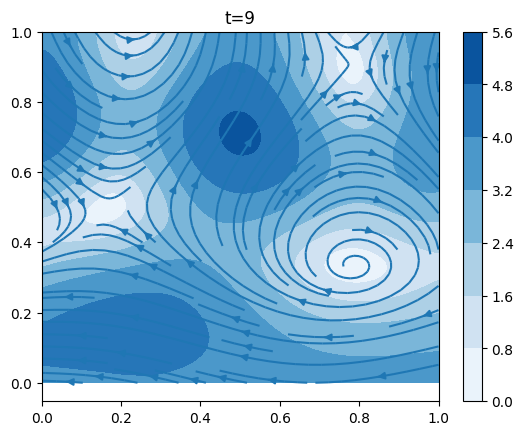

In [46]:
h=w=100
nt = 10
octave_tuple=(1, 1, 1)
perlin_vel = Perlin_volocity_field(nt, h, w,octave_tuple=octave_tuple, 
                                   scale=400, animate=False,
                                #    seed=1,
                                   )
perlin_vel.generate_velocity_field()
perlin_vel.plot_velocity_field(0)
perlin_vel.generate_png_images()


In [47]:
perlin_vel.animate_velocity_field(duration=0.4, animation_path='perlin_field__.gif')

In [72]:
import random
random_number = tuple(random.randint(2, 5) for _ in range(3))
random_number

(4, 2, 3)

In [57]:
perlin_vel.vel.shape

(2, 2, 100, 100)

In [19]:
vel = perlin_vel.vel


In [26]:
vel2 =vel.transpose(1,0,2,3)

In [33]:
vel2[:,0].shape

(120, 100, 100)

In [28]:
np.save('/home/rohit/Documents/Research/Planning_with_transformers/Translation_transformer/my-translat-transformer/data/Matlab_data/vx_vy.npy', perlin_vel.vel)

In [ ]:
vx = grads[0]
vy = grads[1]

t = 0
X,Y = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
plt.streamplot(X,Y,vx[t], vy[t])
vmag_t = np.sqrt(vx[t]**2 + vy[t]**2)
plt.contourf(X,Y,vmag_t, cmap='Blues')

In [ ]:
# make the flow divergence free
def make_divergence_free(vx, vy):
    """This function makes the flow divergence free"""
    
    # Calculate the divergence
    divergence = np.gradient(vx)[1] + np.gradient(vy)[0]
    
    # Subtract the divergence from the y-component of the velocity
    vy -= np.gradient(divergence)[0]
    
    return vx, vy


# Call the function to make the flow divergence free
vx_t, vy_t = make_divergence_free(vx[t], vy[t])
plt.streamplot(X,Y,vx_t, vy_t)
plt.contourf(X,Y,vmag_t, cmap='Blues')

In [64]:
class make_gif:
    def __init__(self, data_path, r):
        self.r = r
        self.h = 100
        self.w = 100
        self.ui = np.load(data_path +'all_ui_mat.npy')
        self.vi = np.load(data_path +'all_vi_mat.npy')
        self.u = np.load(data_path +'all_u_mat.npy')
        self.v = np.load(data_path +'all_v_mat.npy')
        self.Yi = np.load(data_path +'all_Yi.npy')
        self.nt = 120

    def plot_vel_field(self,ax, t, g_strmplot_lw=1, g_strmplot_arrowsize=1):
        # Make modes the last axis T m H W
        Ui = np.transpose(self.ui ,(0,2,3,1))
        Vi = np.transpose(self.vi,(0,2,3,1))
        vx_grid = self.u[t,:,:] + np.dot(Ui[t,:,:,:],self.Yi[t,self.r,:])
        vy_grid = self.v[t,:,:] + np.dot(Vi[t,:,:,:],self.Yi[t,self.r,:])
        vx_grid = np.flipud(vx_grid)
        vy_grid = np.flipud(vy_grid)
        Xs = np.arange(0,self.w) 
        Ys = np.arange(0,self.h)
        X,Y = np.meshgrid(Xs, Ys)
        ax.cla()
        ax.streamplot(X, Y, vx_grid, vy_grid, color = 'grey', zorder = 0,  linewidth=g_strmplot_lw, arrowsize=g_strmplot_arrowsize, arrowstyle='->')
        v_mag_grid = (vx_grid**2 + vy_grid**2)**0.5
        im = ax.contourf(X, Y, v_mag_grid, cmap = "Blues", zorder = -1e5) #, alpha = 0.5, zorder = -1e5)
        v_max = np.max(v_mag_grid)
        # print(v_max)

        return im

    def setup_ax(self, ax, tick_fs = 12):
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim([0,self.w])
        ax.set_ylim([0,self.h])
        xticks = np.arange(0,self.w +20,20)
        yticks = xticks.copy()
        ax.xaxis.set_ticks(xticks)
        ax.yaxis.set_ticks(yticks)
        ax.set_xticklabels(xticks, fontsize=tick_fs)
        ax.set_yticklabels(yticks, fontsize=tick_fs)
    
    def generate_png_images(self):
        fig, ax = plt.subplots()
        self.setup_ax(ax)

        for t in range(self.nt):
            im = self.plot_vel_field(ax,t=t)
            cbar_fontsize = 12
            cbarv = fig.colorbar(im, ax=ax)
            plt.savefig(f'dg3_mp4/figs/dg3_field_{t}.png')
            cbarv.remove()


    def animate_velocity_field(self, duration=.25):
        animation_path = f'dg3_mp4/dg3_{self.r}.gif'
    # def animate_velocity_field(self, animation_path='perlin_noise_3d.gif'):
        if animation_path is not None:
            images = [imageio.imread(f"dg3_mp4/figs/dg3_field_{t}.png") for t in range(self.nt)]
            imageio.mimwrite(animation_path, images, duration=duration)

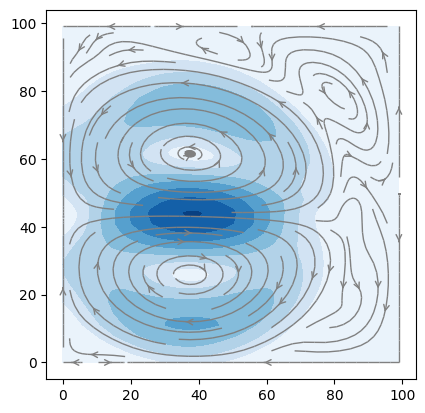

In [51]:
gif = make_gif('/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/GPT_dset_DG3/static_obs/GPTdset_DG3_g100x100x120_r5k_Obsv1_30355/', 4500)
gif.generate_png_images()

In [75]:
gif.animate_velocity_field()

KeyboardInterrupt: 

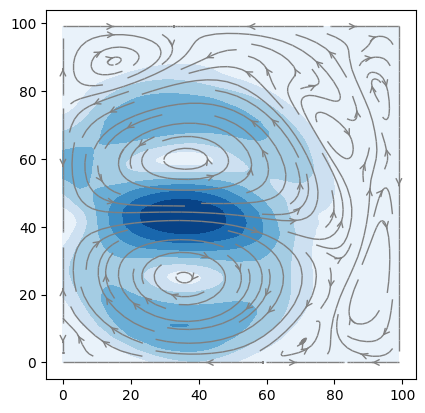

In [94]:
gif = make_gif('/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/GPT_dset_DG3/static_obs/GPTdset_DG3_g100x100x120_r5k_Obsv1_30355/', 2891)
gif.generate_png_images()

In [97]:
import os

directory = "/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_"
# /media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_
# paths = []
# for file in os.listdir(directory):
#     paths.append(os.path.join(directory, file))
#     # print(os.path.join(directory, file))

# print(paths.sort)
for i in range(4000,10000,1):
    print(directory+f'{i}')

/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_4000
/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_4001
/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_4002
/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_4003
/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_4004
/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_4005
/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_4006
/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_4007
/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_4008
/media/HDD/rohit/Translation_transformer/my-translat-transformer/data/Perlin/Perlin_g50x50x60_4009
/media/HDD